In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import yfinance as yf

# Initial Inspection of Data

In [2]:
gold_df = pd.read_csv("gold_backtest_1y.csv", parse_dates=["signal_date", "entry_date"])
gold_df

,signal_date,entry_date,asset,headline_summary,sentiment_score,signal,entry_price,price_1d,price_3d,price_7d
0,2025-08-15,2025-08-18,GC=F,China's New Physical Gold Mandate For Insuranc...,0.386454,⚪ HOLD,3333.500000,3313.399902,3336.899902,3404.600098
1,2025-08-18,2025-08-19,GC=F,Royalty And Streaming Giants Report Blockbuste...,-0.003793,⚪ HOLD,3330.199951,3343.399902,3374.399902,3431.800049
2,2025-08-19,2025-08-20,GC=F,Update: Gold Trading Lower as the Dollar Rises...,-0.176737,⚪ HOLD,3310.600098,3336.899902,3373.800049,3473.699951
3,2025-08-20,2025-08-21,GC=F,Update: Gold Rises For the First Day in Five a...,0.464235,⚪ HOLD,3349.399902,3374.399902,3388.600098,3549.399902
4,2025-08-21,2025-08-22,GC=F,Update: Gold Edges Down as Dollar and Yields R...,-0.564198,🔴 SELL,3349.399902,3373.800049,3404.600098,3593.199951
...,...,...,...,...,...,...,...,...,...,...
234,2026-07-23,2026-07-24,GC=F,What Is Going On With Gold? | ‘Big Short’ Bill...,-0.277151,🔴 SELL,4067.600098,4074.500000,4034.699951,NaN
235,2026-07-24,2026-07-27,GC=F,The One Bond Chart That Keeps Me Up At Night |...,0.018303,⚪ HOLD,4090.100098,4036.300049,4100.100098,NaN
236,2026-07-27,2026-07-28,GC=F,Real Assets Are Beating Tech Right Now. Here's...,-0.178977,⚪ HOLD,4025.699951,4034.699951,NaN,NaN
237,2026-07-28,2026-07-29,GC=F,Commodities: Oil Slides As Hopes Grow For A U....,-0.941129,🔴 SELL,4018.100098,4100.100098,NaN,NaN


In [3]:
btc_df = pd.read_csv("btc_backtest_1y.csv", parse_dates=["signal_date", "entry_date"])
btc_df

,signal_date,entry_date,asset,headline_summary,sentiment_score,signal,entry_price,price_1d,price_3d,price_7d
0,2025-08-15,2025-08-16,BTC-USD,"Markets Weekly Outlook: Jackson Hole, NZ Rate ...",0.463043,🟢 BUY,117398.421875,117453.062500,112831.179688,115374.328125
1,2025-08-18,2025-08-19,BTC-USD,Cryptocurrencies Extend Their Decline From Rec...,-0.242699,🔴 SELL,116241.859375,114274.742188,116874.085938,111802.656250
2,2025-08-19,2025-08-20,BTC-USD,VanEck Mid-August 2025 Bitcoin ChainCheck,0.000000,⚪ HOLD,112828.023438,112419.031250,115374.328125,111222.062500
3,2025-08-20,2025-08-21,BTC-USD,Cryptocurrencies: Bitcoin Quickly Retreats Fro...,-0.482496,🔴 SELL,114275.687500,116874.085938,113458.429688,112544.804688
4,2025-08-22,2025-08-23,BTC-USD,Dow Jones New All-Time Highs: Market Reactions...,0.000000,⚪ HOLD,116866.367188,113458.429688,111802.656250,108808.070312
...,...,...,...,...,...,...,...,...,...,...
213,2026-07-25,2026-07-26,BTC-USD,Weekly Commentary: Bond Yield Breakout,0.000000,⚪ HOLD,64311.785156,63724.898438,63908.167969,NaN
214,2026-07-26,2026-07-27,BTC-USD,Savannah Guthrie Posts New Plea To Mom’s Capto...,-0.191695,⚪ HOLD,65340.589844,63871.363281,64725.308594,NaN
215,2026-07-27,2026-07-28,BTC-USD,Crypto hedge fund manager gets 37 months in pr...,0.215268,🟢 BUY,63723.488281,63908.167969,NaN,NaN
216,2026-07-28,2026-07-29,BTC-USD,"FBTC: Self-Custody Was The Pitch, Now There's ...",0.000000,⚪ HOLD,63871.394531,64725.308594,NaN,NaN


In [ ]:
print(gold_df.info())
print(btc_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   signal_date       239 non-null    datetime64[ns]
 1   entry_date        239 non-null    datetime64[ns]
 2   asset             239 non-null    object        
 3   headline_summary  239 non-null    object        
 4   sentiment_score   239 non-null    float64       
 5   signal            239 non-null    object        
 6   entry_price       239 non-null    float64       
 7   price_1d          238 non-null    float64       
 8   price_3d          236 non-null    float64       
 9   price_7d          232 non-null    float64       
dtypes: datetime64[ns](2), float64(5), object(3)
memory usage: 18.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------

# Comprehensive Asset Performance and Signal Breakdown

### Backtest Evaluation Functions

This section defines all the necessary functions for comprehensive backtest evaluation, including calculating various performance metrics and providing a directional breakdown.

In [4]:
HORIZONS = ["price_1d", "price_3d", "price_7d"]

def _direction(signal: str) -> int:
    """Converts a signal string (e.g., '🟢 BUY') to a numerical direction (1, -1, or 0)."""
    if "BUY" in signal:
        return 1
    if "SELL" in signal:
        return -1
    return 0

def evaluate_horizon(df: pd.DataFrame, horizon_col: str) -> dict:
    """Evaluates trading performance for a given horizon column."""
    trades = df[df["signal"].apply(_direction) != 0].copy()
    trades = trades.dropna(subset=[horizon_col, "entry_price"])
    if trades.empty:
        return {"horizon": horizon_col, "n_trades": 0}

    direction = trades["signal"].apply(_direction)
    trades["return"] = direction * (trades[horizon_col] - trades["entry_price"]) / trades["entry_price"]

    gains = trades.loc[trades["return"] > 0, "return"].sum()
    losses = trades.loc[trades["return"] < 0, "return"].sum()
    profit_factor = gains / abs(losses) if losses != 0 else np.inf

    n = len(trades)
    accuracy = (trades["return"] > 0).mean()
    se = np.sqrt(accuracy * (1 - accuracy) / n) if n > 0 else 0
    acc_ci_low, acc_ci_high = accuracy - 1.96 * se, accuracy + 1.96 * se

    cumulative_return = (1 + trades["return"]).prod() - 1

    return {
        "horizon": horizon_col,
        "n_trades": n,
        "signal_accuracy": accuracy,
        "accuracy_95ci": f"[{acc_ci_low:.2f}, {acc_ci_high:.2f}]",
        "avg_return_per_trade": trades["return"].mean(),
        "profit_factor": profit_factor,
        "cumulative_return": cumulative_return,
    }

def buy_and_hold_return(df: pd.DataFrame, horizon_col: str) -> float:
    """Calculates buy and hold return for the same time window as the strategy's trades."""
    valid = df.dropna(subset=[horizon_col, "entry_price"])
    if valid.empty:
        return np.nan
    start_price = valid["entry_price"].iloc[0]
    end_price = valid[horizon_col].iloc[-1]
    return (end_price - start_price) / start_price

def evaluate_direction(df: pd.DataFrame, horizon_col: str, want_direction: int) -> dict:
    """Same scoring as evaluate_horizon, but scoped to only BUY
    (want_direction=1) or only SELL (want_direction=-1) -- isolates whether
    one side of the asymmetric signal logic (BUY needs trend+sentiment,
    SELL needs only sentiment) is carrying or dragging down the combined
    result."""
    trades = df[df["signal"].apply(_direction) == want_direction].copy()
    trades = trades.dropna(subset=[horizon_col, "entry_price"])
    if trades.empty:
        return {"horizon": horizon_col, "n_trades": 0}

    trades["return"] = want_direction * (trades[horizon_col] - trades["entry_price"]) / trades["entry_price"]

    gains = trades.loc[trades["return"] > 0, "return"].sum()
    losses = trades.loc[trades["return"] < 0, "return"].sum()
    profit_factor = gains / abs(losses) if losses != 0 else np.inf

    n = len(trades)
    accuracy = (trades["return"] > 0).mean()
    se = np.sqrt(accuracy * (1 - accuracy) / n) if n > 0 else 0
    acc_ci_low, acc_ci_high = accuracy - 1.96 * se, accuracy + 1.96 * se

    return {
        "horizon": horizon_col,
        "n_trades": n,
        "signal_accuracy": accuracy,
        "accuracy_95ci": f"[{acc_ci_low:.2f}, {acc_ci_high:.2f}]",
        "avg_return_per_trade": trades["return"].mean(),
        "profit_factor": profit_factor,
    }

def run_direction_breakdown(df: pd.DataFrame, asset_label: str) -> pd.DataFrame:
    """Runs a direction-specific backtest report for a given DataFrame and asset label."""
    rows = []
    for h in HORIZONS:
        buy_row = evaluate_direction(df, h, 1)
        buy_row["signal_type"] = "BUY"
        sell_row = evaluate_direction(df, h, -1)
        sell_row["signal_type"] = "SELL"
        rows.extend([buy_row, sell_row])
    report = pd.DataFrame(rows)
    report.insert(0, "asset", asset_label)
    cols = ["asset", "signal_type", "horizon", "n_trades", "signal_accuracy",
            "accuracy_95ci", "avg_return_per_trade", "profit_factor"]
    return report[cols]

def sample_headlines(df: pd.DataFrame, n: int = 15, seed: int = 42) -> pd.DataFrame:
    """Quick manual spot-check: a random sample of real headline summaries
    with their dates -- read through these and honestly judge whether
    they're actual news events or recurring commentary columns."""
    sample = df.sample(n=min(n, len(df)), random_state=seed)
    return sample[["signal_date", "signal", "sentiment_score", "headline_summary"]].sort_values("signal_date")

# ------------------------------------------------------------------ #
# BENCHMARKS: base rate / trend-only / sentiment-only vs the current
# combined signal, so accuracy can be judged against naive drift/trend
# rather than just against a 50% coin flip.
# ------------------------------------------------------------------ #

def attach_price_trend(df: pd.DataFrame, ticker: str, ma_window: int = 50) -> pd.DataFrame:
    """The original CSV export didn't include the signal-day close or MA50
    (only entry_price/price_Nd), so a trend-only benchmark needs them
    merged in. This only re-pulls price data (fast, no rate limits) --
    no need to re-run the full news-fetching backtest to get this."""
    start = df["signal_date"].min()
    end = df["signal_date"].max()
    buffer_start = (pd.Timestamp(start) - pd.Timedelta(days=int(ma_window * 1.6) + 15)).strftime("%Y-%m-%d")
    end_str = (pd.Timestamp(end) + pd.Timedelta(days=5)).strftime("%Y-%m-%d")

    hist = yf.Ticker(ticker).history(start=buffer_start, end=end_str)
    hist = hist[["Close"]].dropna()
    hist["ma_50"] = hist["Close"].rolling(window=ma_window).mean()
    hist = hist.reset_index()
    hist["signal_date"] = pd.to_datetime(hist["Date"]).dt.tz_localize(None).dt.normalize()

    merged = df.copy()
    merged["signal_date"] = pd.to_datetime(merged["signal_date"])
    merged = merged.merge(hist[["signal_date", "Close", "ma_50"]], on="signal_date", how="left")
    return merged.rename(columns={"Close": "price_at_signal"})


def base_rate(df: pd.DataFrame, horizon_col: str) -> float:
    """Of all days regardless of any signal, what fraction actually moved
    up over this horizon? This is the number "always guess up" or "always
    guess down" (whichever matches the year's drift) would score."""
    valid = df.dropna(subset=[horizon_col, "entry_price"])
    if valid.empty:
        return np.nan
    return (valid[horizon_col] > valid["entry_price"]).mean()


def trend_only_direction(df: pd.DataFrame) -> np.ndarray:
    return np.where(df["price_at_signal"] > df["ma_50"], 1,
                     np.where(df["price_at_signal"] < df["ma_50"], -1, 0))


def sentiment_only_direction(df: pd.DataFrame, threshold: float = 0.0) -> np.ndarray:
    """Symmetric by construction -- same rule for predicting up as for
    predicting down, unlike the current SignalEngine's BUY (trend AND
    sentiment) vs SELL (sentiment alone)."""
    return np.where(df["sentiment_score"] > threshold, 1,
                     np.where(df["sentiment_score"] < -threshold, -1, 0))


def evaluate_ablation(df: pd.DataFrame, horizon_col: str, direction: np.ndarray, method_label: str) -> dict:
    d = df.copy()
    d["pred"] = direction
    trades = d[d["pred"] != 0].dropna(subset=[horizon_col, "entry_price"])
    if trades.empty:
        return {"method": method_label, "horizon": horizon_col, "n_trades": 0}

    trades["return"] = trades["pred"] * (trades[horizon_col] - trades["entry_price"]) / trades["entry_price"]
    n = len(trades)
    accuracy = (trades["return"] > 0).mean()
    se = np.sqrt(accuracy * (1 - accuracy) / n) if n > 0 else 0

    return {
        "method": method_label,
        "horizon": horizon_col,
        "n_trades": n,
        "accuracy": accuracy,
        "accuracy_95ci": f"[{accuracy - 1.96 * se:.2f}, {accuracy + 1.96 * se:.2f}]",
        "avg_return_per_trade": trades["return"].mean(),
    }


def run_benchmark_comparison(df: pd.DataFrame, ticker: str, asset_label: str) -> pd.DataFrame:
    df = attach_price_trend(df, ticker)

    combined_direction = df["signal"].apply(_direction).values
    trend_direction = trend_only_direction(df)
    sentiment_direction = sentiment_only_direction(df)

    rows = []
    for h in HORIZONS:
        rows.append({"method": "base_rate", "horizon": h, "n_trades": None,
                      "accuracy": base_rate(df, h), "accuracy_95ci": None, "avg_return_per_trade": None})
        rows.append(evaluate_ablation(df, h, trend_direction, "trend_only"))
        rows.append(evaluate_ablation(df, h, sentiment_direction, "sentiment_only"))
        rows.append(evaluate_ablation(df, h, combined_direction, "current_combined_signal"))

    report = pd.DataFrame(rows)
    report.insert(0, "asset", asset_label)
    return report

def run_report(df: pd.DataFrame, asset_label: str) -> pd.DataFrame:
    """Runs a full backtest report for a given DataFrame and asset label."""
    rows = [evaluate_horizon(df, h) for h in HORIZONS]
    report = pd.DataFrame(rows)
    report["buy_and_hold_return"] = [buy_and_hold_return(df, h) for h in HORIZONS]
    report.insert(0, "asset", asset_label)
    return report

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

### Generate and Display Gold Backtest Report (Combined BUY+SELL)

In [5]:
gold_report = run_report(gold_df, "Gold")
display(gold_report)

,asset,horizon,n_trades,signal_accuracy,accuracy_95ci,avg_return_per_trade,profit_factor,cumulative_return,buy_and_hold_return
0,Gold,price_1d,98,0.510204,"[0.41, 0.61]",0.004389,1.763558,0.488893,0.229969
1,Gold,price_3d,97,0.597938,"[0.50, 0.70]",0.004446,1.442810,0.462121,0.229969
2,Gold,price_7d,96,0.572917,"[0.47, 0.67]",0.004660,1.273132,0.396100,0.229969


### Generate and Display Bitcoin Backtest Report (Combined BUY+SELL)

In [6]:
btc_report = run_report(btc_df, "Bitcoin")
display(btc_report)

,asset,horizon,n_trades,signal_accuracy,accuracy_95ci,avg_return_per_trade,profit_factor,cumulative_return,buy_and_hold_return
0,Bitcoin,price_1d,78,0.538462,"[0.43, 0.65]",0.001658,1.136956,0.078023,-0.44867
1,Bitcoin,price_3d,77,0.480519,"[0.37, 0.59]",0.001004,1.062248,0.005890,-0.44867
2,Bitcoin,price_7d,76,0.526316,"[0.41, 0.64]",0.009950,1.499376,0.825266,-0.44867


### Directional Breakdown: Gold (BUY vs SELL)

In [7]:
gold_breakdown = run_direction_breakdown(gold_df, "Gold")
display(gold_breakdown)

,asset,signal_type,horizon,n_trades,signal_accuracy,accuracy_95ci,avg_return_per_trade,profit_factor
0,Gold,BUY,price_1d,34,0.647059,"[0.49, 0.81]",0.006165,2.928707
1,Gold,SELL,price_1d,64,0.437500,"[0.32, 0.56]",0.003445,1.484987
2,Gold,BUY,price_3d,34,0.764706,"[0.62, 0.91]",0.012276,3.249823
3,Gold,SELL,price_3d,63,0.507937,"[0.38, 0.63]",0.000221,1.017646
4,Gold,BUY,price_7d,34,0.823529,"[0.70, 0.95]",0.024494,5.757389
5,Gold,SELL,price_7d,62,0.435484,"[0.31, 0.56]",-0.006216,0.736565


### Directional Breakdown: Bitcoin (BUY vs SELL)

In [8]:
btc_breakdown = run_direction_breakdown(btc_df, "Bitcoin")
display(btc_breakdown)

,asset,signal_type,horizon,n_trades,signal_accuracy,accuracy_95ci,avg_return_per_trade,profit_factor
0,Bitcoin,BUY,price_1d,24,0.500000,"[0.30, 0.70]",-0.004087,0.688999
1,Bitcoin,SELL,price_1d,54,0.555556,"[0.42, 0.69]",0.004211,1.361733
2,Bitcoin,BUY,price_3d,23,0.347826,"[0.15, 0.54]",-0.009821,0.576828
3,Bitcoin,SELL,price_3d,54,0.537037,"[0.40, 0.67]",0.005615,1.428224
4,Bitcoin,BUY,price_7d,23,0.434783,"[0.23, 0.64]",-0.009825,0.684824
5,Bitcoin,SELL,price_7d,53,0.566038,"[0.43, 0.70]",0.018531,2.231797


### Sample Headlines for Gold

In [ ]:
display(sample_headlines(gold_df))

,signal_date,signal,sentiment_score,headline_summary
6,2025-08-25,🟢 BUY,0.865147,Commodities: Jerome Powell Provides A Boost To...
9,2025-08-28,⚪ HOLD,0.000000,Copper And Silver Are Setting Up For Powerful ...
24,2025-09-19,🟢 BUY,0.709649,Update: Gold Edges Up Early Following Two Days...
45,2025-10-20,⚪ HOLD,0.186393,Shares of precious metals stocks are trading h...
86,2025-12-17,🔴 SELL,-0.279213,Precious Metals Royalty And Streaming Companie...
93,2025-12-29,🔴 SELL,-0.386643,"Benzinga Market Summary: S&P Closes Lower, Gol..."
104,2026-01-14,⚪ HOLD,-0.042122,GLDI: Upside Potential Is Capped | CNBC Halfti...
109,2026-01-22,⚪ HOLD,0.185457,$1000 Invested In SPDR Gold Shares 10 Years Ag...
113,2026-01-28,🔴 SELL,-0.285509,Powell Defends Fed Independence – But Gold Is ...
114,2026-01-29,🔴 SELL,-0.662943,Commodities: Oil Increasingly Nervous About Po...


### Sample Headlines for Bitcoin

In [ ]:
display(sample_headlines(btc_df))

,signal_date,signal,sentiment_score,headline_summary
9,2025-09-05,⚪ HOLD,0.000000,VanEck Crypto Monthly Recap For August 2025
15,2025-09-17,⚪ HOLD,0.000000,FBI Director Kash Patel Bought 2 Stocks In 202...
30,2025-10-08,🟢 BUY,0.253797,Institutional Wave Pushes Bitcoin ETFs Toward ...
67,2025-12-12,⚪ HOLD,0.000000,Bitcoin Yield 2026: Will Hashrate Become Wall ...
73,2025-12-23,⚪ HOLD,0.000000,VanEck Mid-December 2025 Bitcoin ChainCheck
100,2026-02-06,⚪ HOLD,-0.092293,"This Week's Market Wrap: Crypto Shock, Softwar..."
139,2026-04-01,⚪ HOLD,0.000000,Major Asset Classes: March 2026 Performance Re...
140,2026-04-02,🔴 SELL,-0.483271,"Cool Mara Riot, Part Two: Securities-Fraud Cas..."
154,2026-04-20,⚪ HOLD,0.000000,Bitcoin's Price Outlook: Bitcoin Shrugs Off Sl...
170,2026-05-19,⚪ HOLD,0.000000,MSBT: There's A New Kid On The Block


### Visualization

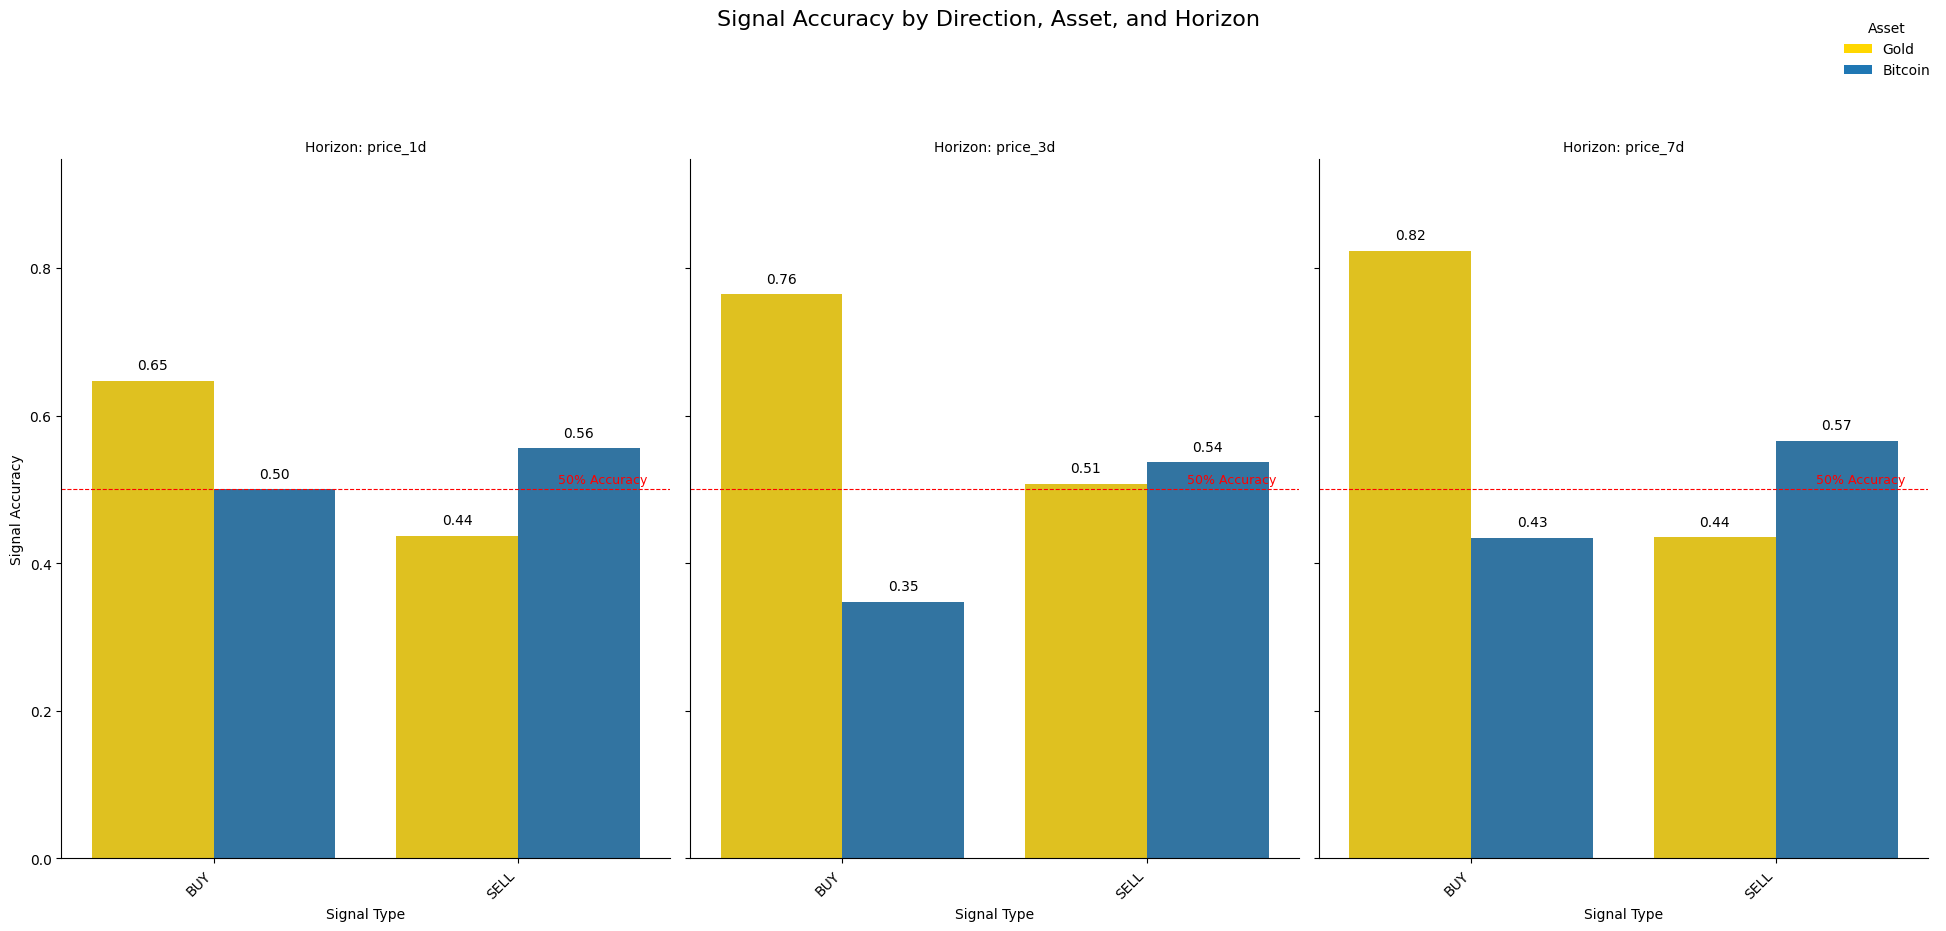

In [9]:
# Concatenate Gold and Bitcoin directional breakdown reports
full_breakdown = pd.concat(
    [gold_breakdown, btc_breakdown],
    ignore_index=True
)

# Ensure accuracy is numeric for plotting
full_breakdown['signal_accuracy'] = pd.to_numeric(
    full_breakdown['signal_accuracy'],
    errors='coerce'
)

# Define colors
asset_colors = {
    'Gold': '#FFD700',
    'Bitcoin': '#1f77b4'
}

# Create the bar plot
fig = sns.catplot(
    data=full_breakdown,
    x='signal_type',
    y='signal_accuracy',
    hue='asset',
    col='horizon',
    kind='bar',
    height=9,
    aspect=0.7,
    palette=asset_colors,
    errorbar=None
)

# Add titles and labels
fig.set_axis_labels(
    "Signal Type",
    "Signal Accuracy"
)

fig.set_titles(
    "Horizon: {col_name}"
)

# Main title
fig.fig.suptitle(
    'Signal Accuracy by Direction, Asset, and Horizon',
    y=1.03,
    fontsize=16
)

# Format each subplot
for ax in fig.axes.flat:

    # Get x-axis labels
    tick_labels = [
        item.get_text()
        for item in ax.get_xticklabels()
    ]

    positions = np.arange(len(tick_labels))

    ax.set_xticks(positions)
    ax.set_xticklabels(
        tick_labels,
        rotation=45,
        ha='right'
    )

    # Give space above the highest bar
    ax.set_ylim(
        0,
        full_breakdown['signal_accuracy'].max() * 1.15
    )

    # Add accuracy values above bars
    for p in ax.patches:

        height = p.get_height()

        if pd.notna(height) and height > 0.005:

            ax.annotate(
                f'{height:.2f}',
                (
                    p.get_x() + p.get_width() / 2,
                    height
                ),
                ha='center',
                va='bottom',
                xytext=(0, 6),
                textcoords='offset points',
                clip_on=False
            )

    # Add 50% accuracy reference line
    ax.axhline(
        0.5,
        color='red',
        linestyle='--',
        linewidth=0.8
    )

    # Add 50% accuracy label
    ax.text(
        ax.get_xlim()[1] * 0.95,
        0.505,
        '50% Accuracy',
        color='red',
        ha='right',
        va='bottom',
        fontsize=9
    )

# Remove the FIGURE-LEVEL legend created by catplot
if fig._legend is not None:
    fig._legend.remove()

# Creating a legend
legend_handles = [
    Patch(
        facecolor=asset_colors['Gold'],
        label='Gold'
    ),
    Patch(
        facecolor=asset_colors['Bitcoin'],
        label='Bitcoin'
    )
]

fig.fig.legend(
    handles=legend_handles,
    title='Asset',
    loc='upper right',
    bbox_to_anchor=(0.98, 1.03),
    frameon=False
)

# Layout
plt.subplots_adjust(
    top=0.86,
    right=0.97
)

plt.tight_layout(
    rect=[0, 0, 0.98, 0.94]
)

plt.show()

# Investigating Trend-Driven vs. Sentiment-Driven Results

This section shows if the results are trend-driven or does the sentiment play any role.

### Backtest Evaluation Functions

In [10]:
"""
Only BUY/SELL rows are scored; HOLD rows are excluded since they represent
no position taken and no directional prediction to check.

Three metrics, on purpose:
  - signal_accuracy: did price actually move in the predicted direction?
  - avg_return_per_trade: direction-adjusted return, averaged across trades
  - profit_factor: total gains / total losses (in absolute value) --
    above 1 means the wins outweighed the losses
"""
HORIZONS = ["price_1d", "price_3d", "price_7d"]


def load_backtest(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=["signal_date", "entry_date"])
    return df.sort_values("signal_date").reset_index(drop=True)


def _direction(signal: str) -> int:
    # SignalEngine's output strings look like "🟢 BUY" / "🔴 SELL" / "⚪ HOLD"
    if "BUY" in signal:
        return 1
    if "SELL" in signal:
        return -1
    return 0


def evaluate_horizon(df: pd.DataFrame, horizon_col: str) -> dict:
    trades = df[df["signal"].apply(_direction) != 0].copy()
    trades = trades.dropna(subset=[horizon_col, "entry_price"])
    if trades.empty:
        return {"horizon": horizon_col, "n_trades": 0}

    direction = trades["signal"].apply(_direction)
    trades["return"] = direction * (trades[horizon_col] - trades["entry_price"]) / trades["entry_price"]

    gains = trades.loc[trades["return"] > 0, "return"].sum()
    losses = trades.loc[trades["return"] < 0, "return"].sum()
    profit_factor = gains / abs(losses) if losses != 0 else np.inf

    n = len(trades)
    accuracy = (trades["return"] > 0).mean()
    # 95% CI on accuracy (normal approximation) -- if this interval contains
    # 0.5, the result isn't distinguishable from a coin flip at this sample size.
    se = np.sqrt(accuracy * (1 - accuracy) / n)
    acc_ci_low, acc_ci_high = accuracy - 1.96 * se, accuracy + 1.96 * se

    cumulative_return = (1 + trades["return"]).prod() - 1

    return {
        "horizon": horizon_col,
        "n_trades": n,
        "signal_accuracy": accuracy,
        "accuracy_95ci": f"[{acc_ci_low:.2f}, {acc_ci_high:.2f}]",
        "avg_return_per_trade": trades["return"].mean(),
        "profit_factor": profit_factor,
        "cumulative_return": cumulative_return,
    }


def buy_and_hold_return(df: pd.DataFrame, horizon_col: str) -> float:
    """Same time window as the strategy's trades for this horizon, so it's
    a fair comparison against cumulative_return above -- not just first
    price vs last price of the whole year regardless of horizon."""
    valid = df.dropna(subset=[horizon_col, "entry_price"])
    if valid.empty:
        return np.nan
    start_price = valid["entry_price"].iloc[0]
    end_price = valid[horizon_col].iloc[-1]
    return (end_price - start_price) / start_price


def evaluate_direction(df: pd.DataFrame, horizon_col: str, want_direction: int) -> dict:
    """Same scoring as evaluate_horizon, but scoped to only BUY
    (want_direction=1) or only SELL (want_direction=-1) -- isolates whether
    one side of the asymmetric signal logic (BUY needs trend+sentiment,
    SELL needs only sentiment) is carrying or dragging down the combined
    result."""
    trades = df[df["signal"].apply(_direction) == want_direction].copy()
    trades = trades.dropna(subset=[horizon_col, "entry_price"])
    if trades.empty:
        return {"horizon": horizon_col, "n_trades": 0}

    trades["return"] = want_direction * (trades[horizon_col] - trades["entry_price"]) / trades["entry_price"]

    gains = trades.loc[trades["return"] > 0, "return"].sum()
    losses = trades.loc[trades["return"] < 0, "return"].sum()
    profit_factor = gains / abs(losses) if losses != 0 else np.inf

    n = len(trades)
    accuracy = (trades["return"] > 0).mean()
    se = np.sqrt(accuracy * (1 - accuracy) / n)
    acc_ci_low, acc_ci_high = accuracy - 1.96 * se, accuracy + 1.96 * se

    return {
        "horizon": horizon_col,
        "n_trades": n,
        "signal_accuracy": accuracy,
        "accuracy_95ci": f"[{acc_ci_low:.2f}, {acc_ci_high:.2f}]",
        "avg_return_per_trade": trades["return"].mean(),
        "profit_factor": profit_factor,
    }


def run_direction_breakdown(csv_path: str, asset_label: str) -> pd.DataFrame:
    df = load_backtest(csv_path)
    rows = []
    for h in HORIZONS:
        buy_row = evaluate_direction(df, h, 1)
        buy_row["signal_type"] = "BUY"
        sell_row = evaluate_direction(df, h, -1)
        sell_row["signal_type"] = "SELL"
        rows.extend([buy_row, sell_row])
    report = pd.DataFrame(rows)
    report.insert(0, "asset", asset_label)
    cols = ["asset", "signal_type", "horizon", "n_trades", "signal_accuracy",
            "accuracy_95ci", "avg_return_per_trade", "profit_factor"]
    return report[cols]


def sample_headlines(csv_path: str, n: int = 15, seed: int = 42) -> pd.DataFrame:
    """Quick manual spot-check: a random sample of real headline summaries
    with their dates -- read through these and honestly judge whether
    they're actual news events or recurring commentary columns."""
    df = load_backtest(csv_path)
    sample = df.sample(n=min(n, len(df)), random_state=seed)
    return sample[["signal_date", "signal", "sentiment_score", "headline_summary"]].sort_values("signal_date")


# ------------------------------------------------------------------ #
# BENCHMARKS: base rate / trend-only / sentiment-only vs the current
# combined signal, so accuracy can be judged against naive drift/trend
# rather than just against a 50% coin flip.
# ------------------------------------------------------------------ #

def attach_price_trend(df: pd.DataFrame, ticker: str, ma_window: int = 50) -> pd.DataFrame:
    """The original CSV export didn't include the signal-day close or MA50
    (only entry_price/price_Nd), so a trend-only benchmark needs them
    merged in. This only re-pulls price data (fast, no rate limits) --
    no need to re-run the full news-fetching backtest to get this."""
    start = df["signal_date"].min()
    end = df["signal_date"].max()
    buffer_start = (pd.Timestamp(start) - pd.Timedelta(days=int(ma_window * 1.6) + 15)).strftime("%Y-%m-%d")
    end_str = (pd.Timestamp(end) + pd.Timedelta(days=5)).strftime("%Y-%m-%d")

    hist = yf.Ticker(ticker).history(start=buffer_start, end=end_str)
    hist = hist[["Close"]].dropna()
    hist["ma_50"] = hist["Close"].rolling(window=ma_window).mean()
    hist = hist.reset_index()
    hist["signal_date"] = pd.to_datetime(hist["Date"]).dt.tz_localize(None).dt.normalize()

    merged = df.copy()
    merged["signal_date"] = pd.to_datetime(merged["signal_date"])
    merged = merged.merge(hist[["signal_date", "Close", "ma_50"]], on="signal_date", how="left")
    return merged.rename(columns={"Close": "price_at_signal"})


def base_rate(df: pd.DataFrame, horizon_col: str) -> float:
    """Of all days regardless of any signal, what fraction actually moved
    up over this horizon? This is the number "always guess up" or "always
    guess down" (whichever matches the year's drift) would score."""
    valid = df.dropna(subset=[horizon_col, "entry_price"])
    if valid.empty:
        return np.nan
    return (valid[horizon_col] > valid["entry_price"]).mean()


def trend_only_direction(df: pd.DataFrame) -> np.ndarray:
    return np.where(df["price_at_signal"] > df["ma_50"], 1,
                     np.where(df["price_at_signal"] < df["ma_50"], -1, 0))


def sentiment_only_direction(df: pd.DataFrame, threshold: float = 0.0) -> np.ndarray:
    """Symmetric by construction -- same rule for predicting up as for
    predicting down, unlike the current SignalEngine's BUY (trend AND
    sentiment) vs SELL (sentiment alone)."""
    return np.where(df["sentiment_score"] > threshold, 1,
                     np.where(df["sentiment_score"] < -threshold, -1, 0))


def evaluate_ablation(df: pd.DataFrame, horizon_col: str, direction: np.ndarray, method_label: str) -> dict:
    d = df.copy()
    d["pred"] = direction
    trades = d[d["pred"] != 0].dropna(subset=[horizon_col, "entry_price"])
    if trades.empty:
        return {"method": method_label, "horizon": horizon_col, "n_trades": 0}

    trades["return"] = trades["pred"] * (trades[horizon_col] - trades["entry_price"]) / trades["entry_price"]
    n = len(trades)
    accuracy = (trades["return"] > 0).mean()
    se = np.sqrt(accuracy * (1 - accuracy) / n)

    return {
        "method": method_label,
        "horizon": horizon_col,
        "n_trades": n,
        "accuracy": accuracy,
        "accuracy_95ci": f"[{accuracy - 1.96 * se:.2f}, {accuracy + 1.96 * se:.2f}]",
        "avg_return_per_trade": trades["return"].mean(),
    }


def run_benchmark_comparison(csv_path: str, ticker: str, asset_label: str) -> pd.DataFrame:
    df = load_backtest(csv_path)
    df = attach_price_trend(df, ticker)

    combined_direction = df["signal"].apply(_direction).values
    trend_direction = trend_only_direction(df)
    sentiment_direction = sentiment_only_direction(df)

    rows = []
    for h in HORIZONS:
        rows.append({"method": "base_rate", "horizon": h, "n_trades": None,
                      "accuracy": base_rate(df, h), "accuracy_95ci": None, "avg_return_per_trade": None})
        rows.append(evaluate_ablation(df, h, trend_direction, "trend_only"))
        rows.append(evaluate_ablation(df, h, sentiment_direction, "sentiment_only"))
        rows.append(evaluate_ablation(df, h, combined_direction, "current_combined_signal"))

    report = pd.DataFrame(rows)
    report.insert(0, "asset", asset_label)
    return report


def run_report(csv_path: str, asset_label: str) -> pd.DataFrame:
    df = load_backtest(csv_path)
    rows = [evaluate_horizon(df, h) for h in HORIZONS]
    report = pd.DataFrame(rows)
    report["buy_and_hold_return"] = [buy_and_hold_return(df, h) for h in HORIZONS]
    report.insert(0, "asset", asset_label)
    return report


if __name__ == "__main__":

    gold_bench = run_benchmark_comparison("gold_backtest_1y.csv", "GC=F", "Gold")
    btc_bench = run_benchmark_comparison("btc_backtest_1y.csv", "BTC-USD", "Bitcoin")
    display(pd.concat([gold_bench, btc_bench], ignore_index=True))


,asset,method,horizon,n_trades,accuracy,accuracy_95ci,avg_return_per_trade
0,Gold,base_rate,price_1d,NaN,0.567227,None,NaN
1,Gold,trend_only,price_1d,238.0,0.567227,"[0.50, 0.63]",0.002314
2,Gold,sentiment_only,price_1d,213.0,0.464789,"[0.40, 0.53]",0.001807
3,Gold,current_combined_signal,price_1d,98.0,0.510204,"[0.41, 0.61]",0.004389
4,Gold,base_rate,price_3d,NaN,0.567797,None,NaN
5,Gold,trend_only,price_3d,236.0,0.644068,"[0.58, 0.71]",0.005581
6,Gold,sentiment_only,price_3d,211.0,0.530806,"[0.46, 0.60]",0.001338
7,Gold,current_combined_signal,price_3d,97.0,0.597938,"[0.50, 0.70]",0.004446
8,Gold,base_rate,price_7d,NaN,0.573276,None,NaN
9,Gold,trend_only,price_7d,232.0,0.625000,"[0.56, 0.69]",0.010812


### Visualization

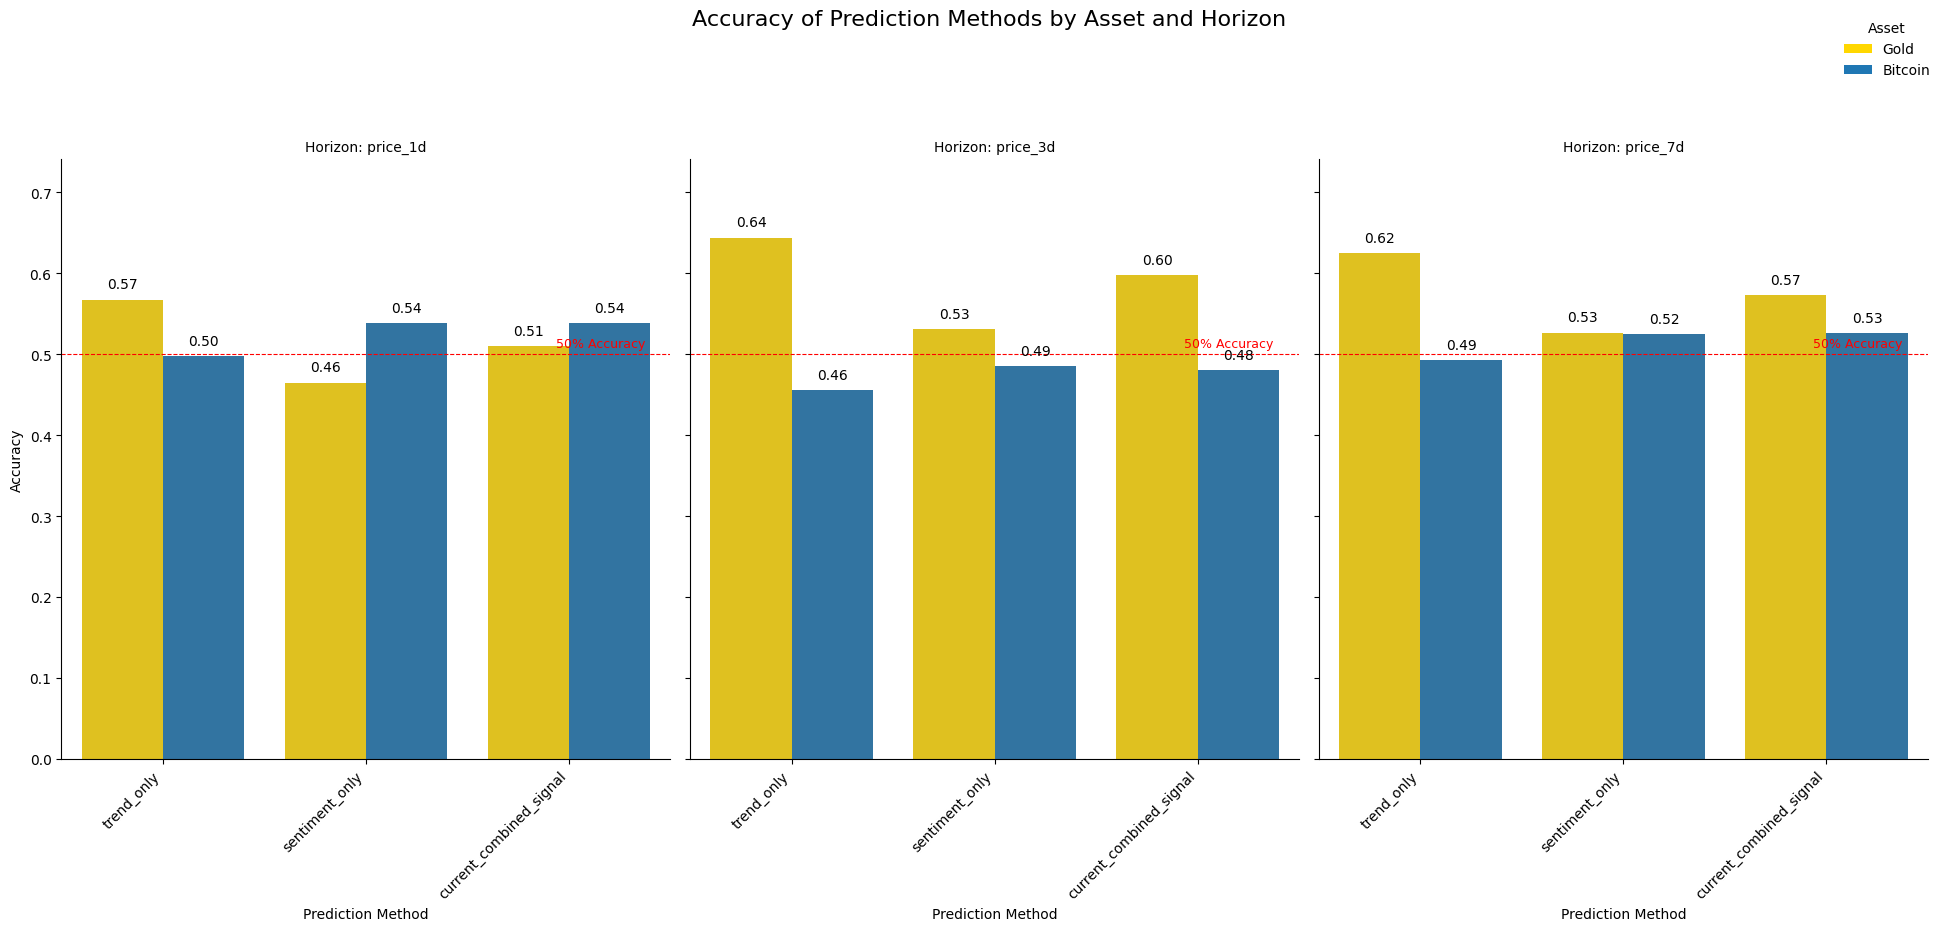

In [12]:
# Combine the benchmark data for plotting
full_benchmark_report = pd.concat(
    [gold_bench, btc_bench],
    ignore_index=True
)

# Filter out the 'base_rate' entries for a clearer comparison
plot_df = full_benchmark_report[
    full_benchmark_report['method'] != 'base_rate'
].copy()

# Ensure accuracy is numeric for plotting
plot_df['accuracy'] = pd.to_numeric(
    plot_df['accuracy'],
    errors='coerce'
)

# Define colors
asset_colors = {
    'Gold': '#FFD700',
    'Bitcoin': '#1f77b4'
}

# Create the bar plot
fig = sns.catplot(
    data=plot_df,
    x='method',
    y='accuracy',
    hue='asset',
    col='horizon',
    kind='bar',
    height=9,
    aspect=0.7,
    palette=asset_colors,
    errorbar=None
)

# Axis labels and subplot titles
fig.set_axis_labels(
    "Prediction Method",
    "Accuracy"
)

fig.set_titles(
    "Horizon: {col_name}"
)

# Main title
fig.fig.suptitle(
    'Accuracy of Prediction Methods by Asset and Horizon',
    y=1.03,
    fontsize=16
)

# Format each subplot
for ax in fig.axes.flat:

    # Get x-axis labels
    tick_labels = [
        item.get_text()
        for item in ax.get_xticklabels()
    ]

    positions = np.arange(len(tick_labels))

    # Set x-axis labels
    ax.set_xticks(positions)
    ax.set_xticklabels(
        tick_labels,
        rotation=45,
        ha='right'
    )

    # Give some space above the bars
    ax.set_ylim(
        0,
        plot_df['accuracy'].max() * 1.15
    )

    # Add accuracy values above each bar
    for p in ax.patches:

        height = p.get_height()

        if pd.notna(height) and height > 0.005:

            ax.annotate(
                f'{height:.2f}',
                (
                    p.get_x() + p.get_width() / 2,
                    height
                ),
                ha='center',
                va='bottom',
                xytext=(0, 6),
                textcoords='offset points',
                clip_on=False
            )

    # Add 50% accuracy reference line
    ax.axhline(
        0.5,
        color='red',
        linestyle='--',
        linewidth=0.8
    )

    # Add 50% accuracy label
    ax.text(
        ax.get_xlim()[1] * 0.95,
        0.505,
        '50% Accuracy',
        color='red',
        ha='right',
        va='bottom',
        fontsize=9
    )

# Remove the FIGURE-LEVEL legend created by catplot
if fig._legend is not None:
    fig._legend.remove()

# Creating legend
legend_handles = [
    Patch(
        facecolor=asset_colors['Gold'],
        label='Gold'
    ),
    Patch(
        facecolor=asset_colors['Bitcoin'],
        label='Bitcoin'
    )
]

fig.fig.legend(
    handles=legend_handles,
    title='Asset',
    loc='upper right',
    bbox_to_anchor=(0.98, 1.03),
    ncol=1,
    frameon=False
)

# Layout
plt.subplots_adjust(
    top=0.86,
    right=0.97
)

plt.tight_layout(
    rect=[0, 0, 0.98, 0.94]
)

plt.show()

### Conclusion: Trend vs. Sentiment Impact

**Gold:** The analysis strongly suggests that Gold's price movements, particularly over longer horizons (3d and 7d), are more **trend-driven**. The `trend_only` method consistently shows higher or comparable accuracy to the `current_combined_signal` and significantly outperforms the `sentiment_only` approach. Furthermore, Gold's `BUY` signals demonstrate remarkably high accuracy (e.g., 82% for 7d horizon), aligning with the combined signal's requirement for both positive trend and sentiment.

**Bitcoin:** In contrast, Bitcoin's performance appears to be more **sentiment-driven**. The `sentiment_only` method often yields better accuracy than the `trend_only` approach and is competitive with the `current_combined_signal`. Bitcoin's `SELL` signals tend to show higher accuracy compared to its `BUY` signals, which aligns with the combined signal's logic where `SELL` signals primarily rely on sentiment.